# NLP Lab-Week 2: Feature Engineering & Representations
---

## Lab Roadmap

| # | Topic |
|---|-------|
| 0 | Setup |
| 1 | Bag of Words & CountVectorizer| 
| 2 | N-gram Models |
| 3 | Named Entity Recognition |
| 4 | POS Tagging |
| 5 | Word Embeddings (Word2Vec & GloVe) |

---

> **Lab philosophy — three layers per section:**
> 1. **Concept block** — read this *before* touching any code
> 2. **Starter code** — runs out of the box; predict the output first
> 3. **✍️ Your turn** — cells with `???` placeholders require your code or written answer
>
> 🟢 Beginner-friendly &nbsp;|&nbsp; 🟡 Intermediate &nbsp;|&nbsp; 🔴 Challenging / Exciting  
> **Golden rule: predict → run → compare. If the output surprises you, that's the learning.**

---
## Section 0: Setup & Library Check

Run **Cell A** (install), then **Cell B** (import).  
Week 2 adds **`gensim`** for Word2Vec and requires the **spaCy medium model** for word vectors.  
First-time installs may take 2-3 minutes; subsequent runs finish in seconds.

In [1]:
# Cell A — install required packages (run once)
import subprocess, sys

LIBS = ["nltk", "spacy", "scikit-learn", "gensim", "pandas", "numpy", "matplotlib","seaborn"]

for lib in LIBS:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", lib])

# spaCy medium model — needed for word vectors in Section 5
subprocess.run([sys.executable, "-m", "spacy", "download", "en_core_web_md"], check=True)

print("All packages installed successfully.")

All packages installed successfully.


In [2]:
# Cell B — imports and NLTK resource downloads
import warnings; warnings.filterwarnings("ignore")

# Standard library
import re
from collections import Counter

# Data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# NLTK
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
for resource in ["punkt", "punkt_tab", "averaged_perceptron_tagger",
                 "averaged_perceptron_tagger_eng", "maxent_ne_chunker",
                 "maxent_ne_chunker_tab", "words", "stopwords"]:
    nltk.download(resource, quiet=True)

# spaCy — medium model has 20k word vectors
import spacy
nlp = spacy.load("en_core_web_md")

# sklearn
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# gensim — Word2Vec
from gensim.models import Word2Vec

STOP_WORDS = set(stopwords.words("english"))

print("Ready. Libraries loaded.")

Ready. Libraries loaded.


---
## Section 1: Bag of Words & CountVectorizer

### Concept

**Bag of Words (BoW)** represents a document as a vector of word counts over a fixed vocabulary. Word *order* is ignored **(only frequencies matter)**.

```
Vocab:              [cat, dog, friends, likes, milk, runs]
"cat likes milk"  → [1,   0,   0,       1,     1,    0  ]
"dog runs"        → [0,   1,   0,       0,     0,    1  ]
```

> **Limitations:** no semantics, no word order, high-dimensional sparse matrix.  
> **Strengths:** fast, interpretable, surprisingly strong baseline.

In [3]:
# STARTER CODE — BoW with sklearn CountVectorizer
# CountVectorizer handles tokenisation, lowercasing, and vocabulary building automatically.

corpus = [
    "the cat sat on the mat",
    "the dog sat on the log",
    "the cat and the dog are friends",
    "cats and dogs never agree",
]

cv = CountVectorizer()          # default: lowercase, strip accents, min_df=1
X  = cv.fit_transform(corpus)  # sparse matrix: shape (n_docs, vocab_size)

# Display as a labelled DataFrame so each cell is readable
df_bow = pd.DataFrame(
    X.toarray(),
    columns=cv.get_feature_names_out(),
    index=[f"Doc {i+1}" for i in range(len(corpus))],
)
print("BoW Matrix:")
print(df_bow)

# Term frequency: total count of each word across all documents
freq  = np.array(X.sum(axis=0)).flatten()
names = cv.get_feature_names_out()
top5  = np.argsort(freq)[::-1][:5]
print("\nTop-5 most frequent terms:", list(zip(names[top5], freq[top5])))

BoW Matrix:
       agree  and  are  cat  cats  dog  dogs  friends  log  mat  never  on  \
Doc 1      0    0    0    1     0    0     0        0    0    1      0   1   
Doc 2      0    0    0    0     0    1     0        0    1    0      0   1   
Doc 3      0    1    1    1     0    1     0        1    0    0      0   0   
Doc 4      1    1    0    0     1    0     1        0    0    0      1   0   

       sat  the  
Doc 1    1    2  
Doc 2    1    2  
Doc 3    0    2  
Doc 4    0    0  

Top-5 most frequent terms: [('the', np.int64(6)), ('sat', np.int64(2)), ('on', np.int64(2)), ('and', np.int64(2)), ('cat', np.int64(2))]


### Reflection Questions **(answer before moving on ✍️)**
1. Which words appear in ALL four documents? What does a column of all-non-zeros tell you?
- none appeared in all the 4 documents. that the word has appeared in all the documents and how many times in a single document.
2. Why is "the" missing from the matrix even though it appears multiple times?
- "The" is not missing.
3. "cats" and "cat" are different columns. What preprocessing step would merge them?
- stemming or lemmatization.

---
### Exercise 1.1: BoW Heatmap: Seeing the Matrix 🟢

**Goal:** Visualise the Bag-of-Words matrix as a colour-coded heatmap so you can immediately see which words are shared across documents and how sparse the matrix is.

**Step-by-step tasks:**
1. Call `sns.heatmap(df_bow, ...)` with `annot=True`, `fmt="d"`, and `cmap="Reds"` so every count appears inside its cell.
2. Add an informative title, x-label (`"Vocabulary"`), and y-label (`"Document"`).
3. Compute the number of zero cells with `(df_bow == 0).sum().sum()` and print the sparsity percentage.
4. Answer the three reflection questions as comments in the cell.


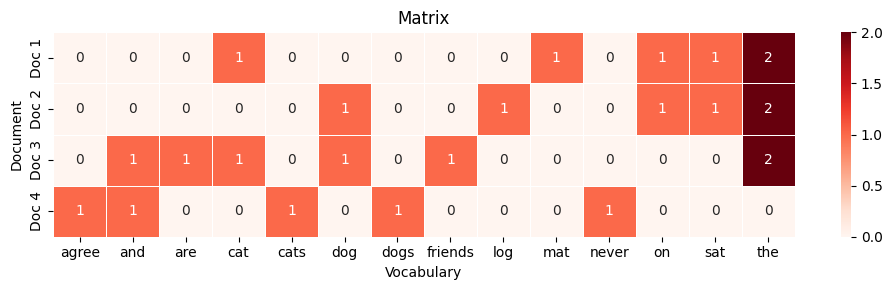

Zero cells: 35 / 56  (62.5% sparse)


In [8]:
# EXERCISE 1.1 🟢 — BoW Heatmap: Seeing the Matrix ✍️
# -------------------------------------------------------
# The starter code printed df_bow as a table of numbers.
# A heatmap makes the same information visual — you can instantly
# see which words are shared across documents and how sparse the
# matrix really is.
#
# TASK:
#   1. Import seaborn as sns.
#   2. Plot df_bow as a heatmap using sns.heatmap().
#      Set annot=True so every count is printed inside its cell,
#      fmt="d" for integer display, and cmap="Reds".
#   3. Add a title, x-label ("Vocabulary") and y-label ("Document").
#   4. Answer the three reflection questions below as comments.
#
# **What you need to know**:
#   sns.heatmap(data, annot=True, fmt="d", cmap="Reds",
#               linewidths=0.5, linecolor="white")
#   plt.title() / plt.xlabel() / plt.ylabel() / plt.tight_layout()
#   plt.show()

import seaborn as sns   # ← new import for this section

# ✍️ YOUR CODE HERE
fig, ax = plt.subplots(figsize=(10, 3))

sns.heatmap(df_bow, annot=True, fmt="d", cmap="Reds",linewidths=0.5, linecolor="white")

plt.title("Matrix")
plt.xlabel("Vocabulary")
plt.ylabel("Document")
plt.tight_layout()
plt.show()

# ✍️ Answer the following as comments:
# Q1. How many cells in the matrix are zero?
#     Count them visually, then compute: (df_bow == 0).sum().sum()
zero_count = 35
total_cells = df_bow.size
print(f"Zero cells: {zero_count} / {total_cells}  "
      f"({zero_count/total_cells*100:.1f}% sparse)")

# Q2. Which word appears in the most documents?
#     Look at the heatmap columns — which column has the fewest white cells?
# ANSWER: The

# Q3. 'sat' appears in Doc 1 and Doc 2 but not Doc 3 or Doc 4.
#     Find one other word with the same pattern.
# ANSWER: On

---
### Exercise 1.2: Preprocessing Impact: Raw vs Cleaned BoW Side-by-Side 🟡

**Goal:** See concretely how stop-word removal and lemmatisation shrink the vocabulary and change sparsity.

**Step-by-step tasks:**
1. Apply the provided `clean_tokens()` function to every review in `reviews` to create `reviews_clean`.
2. Fit a new `CountVectorizer` on `reviews_clean` → `X_clean`, then build `df_clean` exactly as `df_bow` was built in the starter code.
3. Plot `df_raw` and `df_clean` as heatmaps **side by side** using `plt.subplots(1, 2, ...)`.
4. Print vocabulary size, sparsity %, and top-3 tokens for both versions.
5. Answer the reflection question: did sparsity go up or down after cleaning?

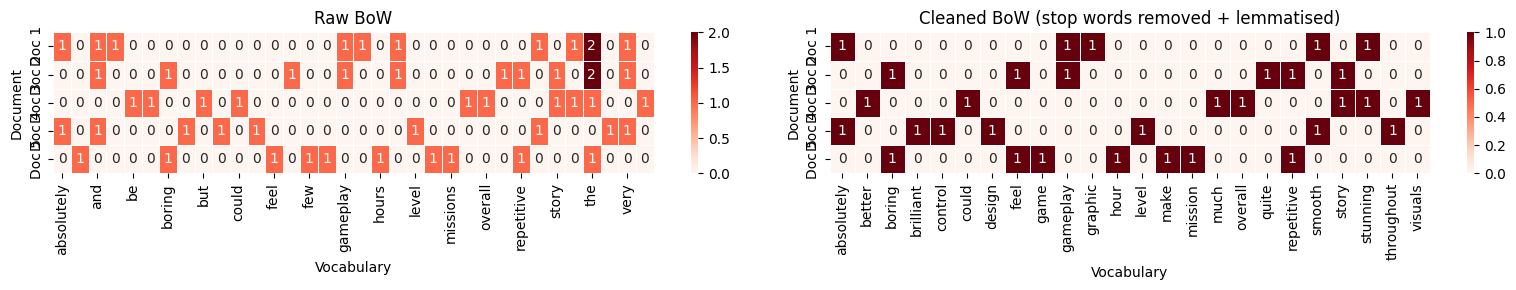

Vocabulary- raw: 34  |  cleaned: 24  
Sparsity- raw: 71.2%  |  cleaned: 73.3%
Top-3 raw  : ['the', 'very', 'and']
Top-3 clean: ['story', 'stunning', 'repetitive']


In [12]:
# EXERCISE 1.2 🟡 — Preprocessing Impact: Raw vs Cleaned BoW Side-by-Side ✍️
# ------------------------------------------------------------------------------
# In Week 1 you built a cleaning pipeline (lowercase, stop-word removal).
# Here you will see exactly what that pipeline does to the BoW matrix.
# The before-and-after heatmaps make the effect visceral.
#
# TASK:
#   1. A minimal clean_tokens() function is provided, read it carefully.
#   2. Apply clean_tokens() to every sentence in `reviews` to produce `reviews_clean`.
#   3. Fit a NEW CountVectorizer on `reviews_clean` → X_clean.
#   4. Build df_clean the same way df_bow was built in the starter code.
#   5. Plot df_bow (raw) and df_clean (cleaned) as heatmaps side-by-side
#      using plt.subplot(1, 2, ...).
#   6. Compute and print:
#        - vocabulary size: raw vs cleaned
#        - sparsity %:      raw vs cleaned
#        - top-3 most frequent tokens: raw vs cleaned
#   7. Answer the reflection question.
#
# What you need to know:
#   fig, axes = plt.subplots(1, 2, figsize=(14, 3))
#   sns.heatmap(df, ax=axes[0], annot=True, fmt="d", cmap="Reds",
#               linewidths=0.5, linecolor="white")
#   axes[0].set_title(...)

from nltk.stem import WordNetLemmatizer
_lemmatizer = WordNetLemmatizer()

def clean_tokens(text):
    """Lowercase → tokenise → remove stop words → lemmatise."""
    tokens = word_tokenize(text.lower())
    tokens = [t for t in tokens if t.isalpha() and t not in STOP_WORDS]
    tokens = [_lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)   # return a string so CountVectorizer can re-tokenise

reviews = [
    "The graphics are absolutely stunning and the gameplay is very smooth",
    "The story is quite boring and the gameplay feels very repetitive",
    "Stunning visuals but the story could be much better overall",
    "Very smooth controls and absolutely brilliant level design throughout",
    "Repetitive missions make the game feel boring after a few hours",
]

# ✍️ Step 1 — clean the corpus
reviews_clean = [clean_tokens(r) for r in reviews]   # apply clean_tokens to each review

# ✍️ Step 2 — build cleaned BoW
cv_clean = CountVectorizer()
X_clean  = cv_clean.fit_transform(reviews_clean)
df_clean = pd.DataFrame(
    X_clean.toarray(),
    columns=cv_clean.get_feature_names_out(),
    index=[f"Doc {i+1}" for i in range(len(reviews))],
)

# Also build raw BoW on same reviews for comparison
cv_raw = CountVectorizer()
X_raw  = cv_raw.fit_transform(reviews)
df_raw = pd.DataFrame(
    X_raw.toarray(),
    columns=cv_raw.get_feature_names_out(),
    index=[f"Doc {i+1}" for i in range(len(reviews))],
)

# ✍️ Step 3 — side-by-side heatmaps
fig, axes = plt.subplots(1, 2, figsize=(16, 3))

sns.heatmap(df_raw,   ax=axes[0], annot=True, fmt="d", cmap="Reds",
            linewidths=0.5, linecolor="white")
axes[0].set_title("Raw BoW")
axes[0].set_xlabel("Vocabulary"); axes[0].set_ylabel("Document")

sns.heatmap(df_clean, ax=axes[1], annot=True, fmt="d", cmap="Reds",
            linewidths=0.5, linecolor="white")
axes[1].set_title("Cleaned BoW (stop words removed + lemmatised)")
axes[1].set_xlabel("Vocabulary"); axes[1].set_ylabel("Document")

plt.tight_layout()
plt.show()

# ✍️ Step 4 — print the comparison numbers
vocab_raw   = len(cv_raw.get_feature_names_out())
vocab_clean = len(cv_clean.get_feature_names_out())

sparse_raw   = (df_raw   == 0).sum().sum() / df_raw.size   * 100
sparse_clean = (df_clean == 0).sum().sum() / df_clean.size * 100

freq_raw   = np.array(X_raw.sum(axis=0)).flatten()
freq_clean = np.array(X_clean.sum(axis=0)).flatten()
top3_raw   = cv_raw.get_feature_names_out()[np.argsort(freq_raw)[::-1][:3]]
top3_clean = cv_clean.get_feature_names_out()[np.argsort(freq_clean)[::-1][:3]]

print(f"Vocabulary- raw: {vocab_raw}  |  cleaned: {vocab_clean}  ")
print(f"Sparsity- raw: {sparse_raw:.1f}%  |  cleaned: {sparse_clean:.1f}%")
print(f"Top-3 raw  : {top3_raw.tolist()}")
print(f"Top-3 clean: {top3_clean.tolist()}")

# ✍️ Reflection:
# Did sparsity go up or down after cleaning? Explain why in one sentence.
# Hint: fewer vocabulary columns but same number of documents.
# ANSWER: because the cleaned bow removed the stop words. Hence there are few vocabulary column but still the same amount of document. 

---
## Section 2: N-gram Models

### Concept

An **n-gram** is a contiguous sequence of *n* tokens. BoW loses word order entirely; n-grams restore *local* order by treating phrases as atomic features.

| n | Name | Example on "I love NLP" | Catches |
|---|------|--------------------------|----------|
| 1 | Unigram | I, love, NLP | Individual word meaning |
| 2 | Bigram | I love, love NLP | Two-word phrases, basic context |
| 3 | Trigram | I love NLP | Three-word chunks, more context |

**Trade-off:** larger n captures more context but creates exponentially more features (data sparsity).  
**Rule of thumb:** unigrams + bigrams (`ngram_range=(1,2)`) is the sweet spot for most tasks.

> **Why bigrams matter for sentiment:** "not good" as a bigram is entirely different from the unigrams "not" + "good" treated separately.

In [ ]:
# STARTER CODE — CountVectorizer with ngram_range

corpus = [
    "I love machine learning very much",
    "machine learning is not easy but rewarding",
    "I love rewarding and challenging problems",
]

for n in [1, 2, 3]:
    vec   = CountVectorizer(ngram_range=(n, n))
    X     = vec.fit_transform(corpus)
    names = vec.get_feature_names_out()
    print(f"\n{n}-gram  ({len(names)} features):")
    print(names)

# Manual bigram building with zip — the Pythonic way
print("\n--- Manual bigrams from sentence 1 ---")
tokens  = corpus[0].split()
bigrams = list(zip(tokens, tokens[1:]))       # pairs of consecutive words
print(Counter(bigrams).most_common(5))

### Reflection Questions ✍️
1. How many unique bigrams does corpus[1] contribute that corpus[0] does not?
2. The phrase "not easy" appears as a bigram. Why would this be lost in unigram BoW?
3. What happens to feature count as you increase n from 1 → 3? Is this a problem?

---
### Exercise 2.1: Count N-grams 🟢

**Goal:** Build unigram, bigram, and trigram counts manually (without sklearn) to understand what n-grams capture that single words miss.

**Step-by-step tasks:**
1. Tokenise `review` with `word_tokenize`.
2. Build `unigrams`, `bigrams`, and `trigrams` using `zip()`.
3. Print the top-3 most common for each using `Counter(...).most_common(3)`.
4. Identify which bigram best captures the negative sentiment of the review.

In [ ]:
# EXERCISE 2.1 🟢 — Count N-grams ✍️
# ----------------------------------------
# TASK: For the `review` string below:
#   1. Extract and count unigrams, bigrams, and trigrams manually (no sklearn)
#   2. Print the top-3 most common for each n
#   3. Which bigram is most informative about sentiment?
#
# HINT: use zip() three times with different offsets
#   bigrams  = list(zip(tokens, tokens[1:]))
#   trigrams = list(zip(tokens, tokens[1:], tokens[2:]))

review = "the movie was not good at all the acting was not convincing and the plot was not interesting"

# ✍️ YOUR CODE HERE
tokens   = word_tokenize(review)
unigrams = ???
bigrams  = ???
trigrams = ???

for label, grams in [("Unigram", unigrams), ("Bigram", bigrams), ("Trigram", trigrams)]:
    print(f"\nTop-3 {label}s:", Counter(grams).most_common(3))

# ✍️ Which bigram best captures the negative sentiment? Write your answer here:
# ANSWER: ???

---
### Exercise 2.2: Bigram Language Model (Probability Estimation) 🟡

**Goal:** Implement a simple bigram language model that estimates `P(word | previous_word)` from raw counts.

**Step-by-step tasks:**
1. Tokenise `training_text`.
2. Count all bigrams: `Counter(zip(tokens, tokens[1:]))`.
3. Count all unigrams: `Counter(tokens)`.
4. For each `(w1, w2)` in `test_pairs`, compute `P(w2 | w1) = count(w1, w2) / count(w1)`.
5. Print the results in the formatted table already provided.


In [ ]:
# EXERCISE 2.2 🟡 — Bigram Language Model (Probability Estimation) ✍️
# ----------------------------------------------------------------------
# A bigram language model estimates P(word | previous_word).
# P(w2 | w1) = count(w1, w2) / count(w1)
#
# TASK:
#   1. Count all bigrams in `training_text`
#   2. Count all unigrams
#   3. For each query pair in `test_pairs`, compute and print P(w2 | w1)
#
# HINTS:
#   bigram_counts  = Counter(zip(tokens, tokens[1:]))
#   unigram_counts = Counter(tokens)
#   prob = bigram_counts[(w1, w2)] / unigram_counts[w1]   # may be 0 if unseen!

training_text = """
the cat sat on the mat the cat ate the rat the dog sat on the log
the dog chased the cat the rat ran from the cat the mat is on the floor
"""

test_pairs = [("cat", "sat"), ("the", "cat"), ("dog", "flew"), ("on", "the")]

# ✍️ YOUR CODE HERE
tokens         = ???
bigram_counts  = ???
unigram_counts = ???

print(f"{'Bigram':<20} {'Count':>6} {'P(w2|w1)':>10}")
print("-" * 40)
for w1, w2 in test_pairs:
    bc   = ???
    uc   = ???
    prob = ???
    print(f"{w1+' '+w2:<20} {bc:>6} {prob:>10.4f}")

---
### Exercise 2.3: Next-Word Prediction with N-gram Model 🔴

**Goal:** Turn the bigram probability model into a simple text generator that predicts the most likely next word at each step.

**Step-by-step tasks:**
1. Complete `predict_next(word)`: find all words `w2` that follow `word` in the bigram counts and return the one with the highest count.
2. Use `predict_next` in a loop to generate a 10-word sentence starting from `"the"`.
3. Reflect on *why* the sentence tends to loop or degenerate.


In [ ]:
# EXERCISE 2.3 🔴 — Next-Word Prediction with N-gram Model ✍️
# ---------------------------------------------------------------------
# TASK: Using the bigram model from Exercise 2.2, write a `predict_next(word)`
#       function that returns the most likely next word.
#       Then generate a 10-word sentence starting from "the".
#
# HINTS:
#   candidates = {w2: bigram_counts[(seed, w2)] for w2 in unigram_counts}
#   return max(candidates, key=candidates.get)   # word with highest count
#   Watch out for infinite loops! Add a stop condition.

# ✍️ YOUR CODE HERE
def predict_next(word):
    # Find all bigrams that start with `word`
    candidates = {w2: bigram_counts.get((word, w2), 0) for w2 in unigram_counts}
    best = ???
    return best

# Generate a sentence
seed     = "the"
sentence = [seed]
for _ in range(9):
    next_word = ???
    sentence.append(next_word)

print("Generated sentence:", " ".join(sentence))

# ✍️ Reflection: why does the sentence loop or repeat?
# ANSWER: ???

---
## Section 3: Named Entity Recognition (NER)

### Concept

**NER** is a two-step task:
1. **Extraction**: identify *spans* of text that are entities
2. **Classification**: assign each span a label: `PERSON`, `ORG`, `GPE` (location), `DATE`, `MONEY`, etc. 

| Approach | Mechanism | Needs training data? | Best for |
|----------|-----------|----------------------|----------|
| Dictionary lookup | match known entity list | No | Closed vocab (drugs, countries) |
| Regex / rules | hand-written patterns | No | Dates, IDs, postcodes |
| HMM / CRF | sequence model on POS + context | Yes | CoNLL benchmark NER |
| spaCy (neural) | CNN + transition parser | Pre-trained | Production NER |

> **Common challenges:** name variation ("Dr. Merkel" vs "Angela Merkel"), ambiguity ("London" = city or person?), domain shift (medical NER needs medical training data).

In [ ]:
# STARTER CODE — spaCy NER vs NLTK rule-based NER

text = "Angela Merkel met Elon Musk in Berlin on Monday to discuss Tesla's €2 billion investment."

# --- spaCy: neural NER pipeline ---
doc = nlp(text)
print("spaCy NER:")
print(f"{'Entity':<25} {'Label':<12} {'Explanation'}")
print("-" * 55)
for ent in doc.ents:
    print(f"{ent.text:<25} {ent.label_:<12} {spacy.explain(ent.label_)}")

# --- NLTK: rule-based (MaxEnt chunker) ---
print("\nNLTK NER (rule-based):")
tokens  = word_tokenize(text)
tagged  = nltk.pos_tag(tokens)     # POS tags are required input for ne_chunk
print(tagged)
chunked = nltk.ne_chunk(tagged, binary=False) # When binary=False, the function performs fine-grained named entity recognition. This means it assigns specific entity labels, for example PERSON, ORGANISATION, GPE (geo-political entity), and so on
for subtree in chunked:
    if hasattr(subtree, "label"):  # named entity chunks have a .label() method
        entity = " ".join(w for w, t in subtree.leaves())
        print(f"  {subtree.label():<12} {entity}")

### Reflection Questions ✍️
1. Does NLTK identify "Tesla" as an ORG? Does spaCy? What explains the difference?
2. How does spaCy handle "€2 billion"? What label does it assign?
3. What would happen if you ran this on a medical text? Which entities would be missed?

---
### Exercise 3.1: Extract Entities from a News Snippet 🟢

**Goal:** Run spaCy's neural NER on a real news paragraph, display each entity with its character offsets, and summarise the distribution of entity types.

**Step-by-step tasks:**
1. Pass `news_text` through `nlp()` to get a `doc`.
2. Print each entity: `ent.text`, `ent.label_`, `ent.start_char`, `ent.end_char`.
3. Count entities per label: `Counter([ent.label_ for ent in doc.ents])`.
4. Print the distribution.


In [ ]:
# EXERCISE 3.1 🟢 — Extract Entities from a News Snippet ✍️
# -----------------------------------------------------------
# TASK:
#   1. Run spaCy NER on `news_text`
#   2. Print each entity with its label and character offsets (ent.start_char, ent.end_char)
#   3. Count how many entities of each label type appear
#   4. Answer the reflection question
#
# HINT: use a Counter over [ent.label_ for ent in doc.ents]

news_text = """
Apple Inc. announced on Tuesday that CEO Tim Cook will visit Tokyo and Seoul next month.
The trip follows a $5 billion investment in South Korean semiconductor firm Samsung.
Analysts at Goldman Sachs expect Apple shares to rise 12% by Q3 2026.
"""

# ✍️ YOUR CODE HERE
doc = ???

print(f"{'Entity':<25} {'Label':<10} {'Start':>6} {'End':>5}")
print("-" * 50)
for ent in doc.ents:
    print(???)

label_counts = Counter(???)
print("\nEntity type distribution:", label_counts)

---
### Exercise 3.2: Rule-based NER with Regex 🟡

**Goal:** Build a dictionary-based regex NER function that extracts structured entities (emails, phones, dates, currency) from text where a general-purpose neural model would struggle.

**Step-by-step tasks:**
1. In `regex_ner`, iterate over the `PATTERNS` dict.
2. For each label, call `re.findall(pattern, text)` to get all matches.
3. Append `(match, label)` for each hit.
4. Return the list sorted by the position of the entity in the original text.

In [ ]:
# EXERCISE 3.2 🟡 — Rule-based NER with Regex ✍️
# -------------------------------------------------
# TASK: Write a regex-based NER function that extracts:
#   - Email addresses     pattern: r'\b[\w.+-]+@[\w-]+\.[\w.]+\b'
#   - Phone numbers       pattern: r'\+?\d[\d\s\-().]{7,}\d'
#   - Dates               pattern: r'\b\d{1,2}[/-]\d{1,2}[/-]\d{2,4}\b'
#   - Currency amounts    pattern: r'[$€£]\s?\d+(?:[.,]\d+)?(?:\s?(?:million|billion|k))?'
#
# Return a list of (entity_text, label) tuples.

structured_text = """
Contact Dr. Smith at j.smith@hospital.org or call +49 6221 123-456.
The appointment is on 15/06/2026. The consultation fee is €250.00.
For billing, reach accounts@billing.de. Emergency line: 112.
"""

PATTERNS = {
    "EMAIL":    r'\b[\w.+-]+@[\w-]+\.[\w.]+\b',
    "PHONE":    r'\+?\d[\d\s\-().]{7,}\d',
    "DATE":     r'\b\d{1,2}[/-]\d{1,2}[/-]\d{2,4}\b',
    "CURRENCY": r'[$€£]\s?\d+(?:[.,]\d+)?(?:\s?(?:million|billion|k))?',
}

# ✍️ YOUR CODE HERE
def regex_ner(text, patterns):
    results = []
    for label, pattern in patterns.items():
        matches = ???
        for match in matches:
            results.append(???)
    return sorted(results, key=lambda x: text.find(x[0]))

entities = regex_ner(structured_text, PATTERNS)
for entity, label in entities:
    print(f"{label:<12} {entity}")

---
### Exercise 3.3: NER on Medical Text: Domain Shift 🔴

**Goal:** Discover the limits of general-purpose NER by comparing spaCy against a hand-crafted medical dictionary, revealing why domain-specific models matter.

**Step-by-step tasks:**
1. Run `nlp(medical_text)` and print all entities spaCy finds.
2. Tokenise `medical_text`, lowercase the tokens, then check each token against every set in `MEDICAL_ENTITIES`.
3. Print every match with its label.
4. Compare the two outputs: which disease/drug terms does spaCy miss?



In [ ]:
# EXERCISE 3.3 🔴 — NER on Medical Text: Domain Shift ✍️
# ----------------------------------------------------------------
# Medical text contains entities that general-purpose NER systems often miss.
#
# TASK:
#   1. Run spaCy NER on `medical_text` — note what it finds and misses
#   2. Build a simple dictionary-based NER for medical entities
#   3. Compare: which entities does spaCy miss that your dictionary catches?
#
# Drug/disease dictionaries are provided — extend them if you like.

medical_text = """
The patient presented with type 2 diabetes and hypertension.
Metformin 500mg was prescribed along with Lisinopril 10mg.
Follow-up with Dr. Patel at Heidelberg University Hospital on 01/07/2026.
"""

MEDICAL_ENTITIES = {
    "DISEASE":  {"diabetes", "hypertension", "asthma", "arthritis", "cancer"},
    "DRUG":     {"metformin", "lisinopril", "ibuprofen", "aspirin", "insulin"},
}

# ✍️ YOUR CODE HERE
# Part 1: spaCy
doc = nlp(medical_text)
print("spaCy finds:")
for ent in doc.ents:
    print(f"  {ent.label_:<10} {ent.text}")

# Part 2: dictionary NER
print("\nDictionary NER finds:")
tokens_lower = ???
for label, entity_set in MEDICAL_ENTITIES.items():
    for token in tokens_lower:
        if ???:
            print(f"  {label:<10} {token}")

---
## Section 4: Part-of-Speech (POS) Tagging

### Concept

**POS tagging** assigns a grammatical label to each token. These labels unlock downstream tasks: parsing, NER, keyword extraction, and feature engineering.

| Universal tag | Penn Treebank tags | Meaning | Example |
|---------------|--------------------|---------|----------|
| NOUN | NN, NNS, NNP, NNPS | Noun (singular, plural, proper) | dog, cats, London |
| VERB | VB, VBZ, VBD, VBG | Verb (base, 3rd-sg, past, gerund) | run, runs, ran |
| ADJ | JJ, JJR, JJS | Adjective (base, comparative, superlative) | fast, faster, fastest |
| ADV | RB, RBR, RBS | Adverb | quickly, not |
| PROPN | NNP | Proper noun | Paris, Tesla |

> **Key insight:** "not" is tagged `RB` (adverb). If you remove adverbs as stop words, you flip the meaning of negations. Thus, always check your task before filtering!

**Two taggers in this lab:**
- `nltk.pos_tag()` → Penn Treebank fine-grained tags (VBZ, NNP…)
- `token.pos_` in spaCy → Universal coarse tags (VERB, NOUN…)  
- `token.tag_` in spaCy → Penn Treebank fine-grained (same scheme as NLTK)

In [ ]:
# STARTER CODE — NLTK vs spaCy POS tagging side-by-side

sentence = "The quick brown fox jumps over the lazy dog."

# NLTK — returns (word, Penn-TB-tag) tuples
nltk_tags = nltk.pos_tag(word_tokenize(sentence))
print("NLTK Penn-TB tags:")
print(nltk_tags)

# spaCy — richer: universal + fine-grained + human-readable explanation
doc = nlp(sentence)
print("\nspaCy tags:")
print(f"{'Token':<12} {'pos_':8} {'tag_':6} Explanation")
print("-" * 55)
for tok in doc:
    print(f"{tok.text:<12} {tok.pos_:<8} {tok.tag_:<6} {spacy.explain(tok.tag_)}")

# Tag distribution
tag_counts = Counter(tok.pos_ for tok in doc)
print("\nTag distribution:", tag_counts.most_common())

### Reflection Questions ✍️
1. What tag does "lazy" receive? Is it the same in NLTK and spaCy?
2. Predict: if you run POS tagging on "I saw her duck" — what is the tag of "duck"? Run it and check.
3. Why is POS tagging a prerequisite for NER?

---
### Exercise 4.1: Tag a Sentence and Count Nouns vs Verbs 🟢

**Goal:** Use spaCy POS tagging to extract all nouns (NOUN + PROPN) and verbs from a paragraph, then judge which nouns best represent the document's topic.

**Step-by-step tasks:**
1. Pass `paragraph` through `nlp()`.
2. Extract `nouns`: tokens where `tok.pos_` is `"NOUN"` or `"PROPN"`.
3. Extract `verbs`: tokens where `tok.pos_` is `"VERB"`.
4. Print both lists with their counts.
5. Identify the 3 nouns that best represent the paragraph topic.



In [ ]:
# EXERCISE 4.1 🟢 — Tag a Sentence and Count Nouns vs Verbs ✍️
# --------------------------------------------------------------
# TASK:
#   1. POS-tag `paragraph` with spaCy
#   2. Extract all NOUNs and PROPNs → `nouns`
#   3. Extract all VERBs → `verbs`
#   4. Print both lists and their counts
#   5. Answer: which nouns could serve as document keywords?
#
# HINT: [tok.text for tok in doc if tok.pos_ == "NOUN"]

paragraph = """
Artificial intelligence is transforming healthcare. Doctors are using machine learning
models to detect cancer earlier and predict patient outcomes. Hospitals in Germany have
reported improved diagnosis rates after deploying AI systems in radiology.
"""

# ✍️ YOUR CODE HERE
doc    = ???
nouns  = ???
verbs  = ???

print(f"Nouns  ({len(nouns)}): {nouns}")
print(f"Verbs  ({len(verbs)}): {verbs}")

# ✍️ Which 3 nouns best represent the topic of this paragraph?
# ANSWER: ???

---
### Exercise 4.2: Extract Noun Phrases with spaCy 🟡

**Goal:** Use spaCy's built-in noun chunk parser to extract multi-word noun phrases and identify their syntactic heads.

**Step-by-step tasks:**
1. Pass `text` through `nlp()`.
2. Iterate over `doc.noun_chunks` and print each chunk's text, root word, and root POS.
3. Decide which noun phrase would make the best document tag.

In [ ]:
# EXERCISE 4.2 🟡 — Extract Noun Phrases with spaCy ✍️
# ------------------------------------------------------
# spaCy's noun chunk parser identifies multi-word noun phrases automatically.
# doc.noun_chunks returns spans like "the quick brown fox", "the lazy dog".
#
# TASK:
#   1. Extract all noun chunks from `text`
#   2. Print each chunk with its root word and root POS
#   3. Which noun phrase would make the best document tag?
#
# HINT: for chunk in doc.noun_chunks:  chunk.text, chunk.root.text, chunk.root.pos_

text = """
The large pre-trained language model from OpenAI has changed natural language processing.
Many research teams at leading universities are now studying its emergent capabilities.
"""

# ✍️ YOUR CODE HERE
doc = ???
print(f"{'Noun Chunk':<40} {'Root Word':<15} {'Root POS'}")
print("-" * 65)
for chunk in ???:
    print(f"{chunk.text:<40} {chunk.root.text:<15} {chunk.root.pos_}")

---
### Exercise 4.3: POS-Filtered Keyword Extraction (BONUS) 🔴

**Goal:** Combine TF-IDF scores with POS filtering to extract only content-bearing keywords (nouns and proper nouns) from a document.

**Step-by-step tasks:**
1. Fit `TfidfVectorizer` on `articles` and get the feature-score vector for article 0.
2. For each token with a non-zero TF-IDF score, look up its POS with `nlp(token)[0].pos_`.
3. Keep only tokens tagged as `"NOUN"` or `"PROPN"`.
4. Sort the kept tokens by score (descending) and print the top 5.

**Hints:**
- `scores_0 = X_art[0].toarray().flatten()` (one score per vocabulary word).
- `if pos in ("NOUN", "PROPN")` then replace the `???` with this tuple check.
- `keyword_candidates.sort(key=lambda x: x[1], reverse=True)` sorts by TF-IDF score.
- Running `nlp(token)[0].pos_` on a single token is slightly slow in a loop; for a large vocabulary consider batching with `nlp.pipe()`.


In [ ]:
# EXERCISE 4.3 🔴 — POS-Filtered Keyword Extraction (BONUS) ✍️
# ---------------------------------------------------------------
# Keyword extraction: high-TF-IDF NOUNs and PROPNs are often the best keywords.
# Strategy: TF-IDF on the whole corpus, then filter to noun/proper-noun tokens only.
#
# TASK:
#   1. Compute TF-IDF on `articles`
#   2. For the first article, get TF-IDF scores for each token
#   3. Keep only tokens whose spaCy POS is NOUN or PROPN
#   4. Return the top-5 by TF-IDF score

articles = [
    "Climate change is causing extreme weather events across Europe and North America",
    "Scientists warn that global temperatures will rise by 2 degrees by 2050",
    "Renewable energy sources like solar and wind are replacing fossil fuels",
    "Carbon emissions from industry and transport are the main drivers of warming",
    "European governments are investing billions in green hydrogen and electric vehicles",
]

# ✍️ YOUR CODE HERE
tfidf  = TfidfVectorizer()
X_art  = tfidf.fit_transform(articles)
feat   = tfidf.get_feature_names_out()

# Scores for article 0
scores_0 = X_art[0].toarray().flatten()

# POS-filter: keep only NOUN / PROPN tokens
keyword_candidates = []
for token, score in zip(feat, scores_0):
    if score > 0:
        pos = nlp(token)[0].pos_
        if pos in ???:
            keyword_candidates.append((token, score, pos))

keyword_candidates.sort(key=lambda x: x[1], reverse=True)
print("Top-5 POS-filtered keywords for Article 1:")
for word, score, pos in keyword_candidates[:5]:
    print(f"  {word:<20} {pos:<8} {score:.4f}")

## Section 5: Word Embeddings (Word2Vec & GloVe) 
### Concept

**Word embeddings** map words to dense vectors (typically 100–300 dimensions) so that similar words have similar vectors. This solves two problems BoW cannot:
- **Semantics:** "king" and "queen" are close; "king" and "banana" are far
- **Generalisation:** unseen combinations can be handled via nearby known words

**Word2Vec: two training objectives:**

| Model | Objective | Better for |
|-------|-----------|------------|
| Continuous Bag of Words (**CBOW**)  | Predict *target* word from surrounding context | Frequent words, large corpora |
| **Skip-gram** | Predict surrounding *context* words from target | Rare words, smaller corpora |

Global Vectors (**GloVe**) uses the global word co-occurrence matrix instead of local windows. Both produce similar-quality vectors in practice.

> **Analogy arithmetic:** the classic demo of embedding quality.  
> `vector("king") − vector("man") + vector("woman") ≈ vector("queen")`  
> This works because the gender dimension is consistent across the vector space.

In [ ]:
# STARTER CODE — Train Word2Vec (CBOW & Skip-gram) with gensim

# Small corpus — in practice you need millions of sentences for good embeddings
sentences_raw = [
    "the king rules the kingdom with wisdom",
    "the queen leads the nation with grace",
    "a man and a woman walked into the palace",
    "the prince and princess attend the royal court",
    "machine learning models learn from data",
    "deep learning uses neural networks",
    "natural language processing is a field of artificial intelligence",
    "word embeddings capture semantic meaning of words",
    "the dog and the cat are common pets",
    "dogs and cats live in many homes",
]

# gensim expects a list of token lists
sentences = [s.split() for s in sentences_raw]

# CBOW: sg=0, predicts target from context
cbow = Word2Vec(sentences, vector_size=50, window=3, sg=0, min_count=1, epochs=200, seed=42)

# Skip-gram: sg=1, predicts context from target
sg_model = Word2Vec(sentences, vector_size=50, window=3, sg=1, min_count=1, epochs=200, seed=42)

# Nearest neighbours
print("CBOW — most similar to 'king':")
print(cbow.wv.most_similar("king", topn=3))

print("\nSkip-gram — most similar to 'king':")
print(sg_model.wv.most_similar("king", topn=3))

# Vector inspection
print(f"\nVector for 'king' (first 10 dims): {cbow.wv['king'][:10]}")
print(f"Vector dimensionality: {cbow.wv.vector_size}")

### Reflection Questions ✍️
1. CBOW and Skip-gram were trained on the same tiny corpus. Do they give the same nearest neighbours?
2. The corpus is very small. How would results change with Wikipedia-scale training data?
3. Why might `min_count=1` be a bad idea for a large corpus?

---
### Exercise 5.1: Find Similar Words with Word2Vec 🟢

**Goal:** Query the trained CBOW model for the nearest neighbours of several seed words and evaluate whether the results make semantic sense.

**What you will practise:**
- Using `model.wv.most_similar()` to retrieve nearest neighbours
- Critically interpreting embedding quality on a small corpus

**Step-by-step tasks:**
1. For each word in `seed_words`, call `cbow.wv.most_similar(word, topn=5)`.
2. Print each neighbour and its cosine similarity score.
3. Reflect on whether the neighbours make sense given the tiny training corpus.

**Hints:**
- Always check `if word in cbow.wv` before querying: `min_count=1` should include all words, but it's good practice.
- `neighbours = cbow.wv.most_similar(word, topn=5)` returns a list of `(word, score)` tuples.
- With only 10 training sentences, neighbours will look "random" compared to a Wikipedia-trained model (that's the expected observation for the reflection).


In [ ]:
# EXERCISE 5.1 🟢 — Find Similar Words with Word2Vec ✍️
# -------------------------------------------------------
# TASK:
#   1. Using the CBOW model trained above, find the top-5 words most similar to each seed word
#   2. Print the word and similarity score for each
#   3. Answer: do the neighbours make semantic sense given the small corpus?
#
# HINT: cbow.wv.most_similar("word", topn=5)

seed_words = ["learning", "queen", "neural"]

# ✍️ YOUR CODE HERE
for word in seed_words:
    if word in cbow.wv:
        neighbours = ???
        print(f"\nMost similar to '{word}':")
        for neighbour, score in neighbours:
            print(f"  {neighbour:<15} {score:.4f}")
    else:
        print(f"'{word}' not in vocabulary")

---
### Exercise 5.2: Analogy: king − man + woman = ? 🟡

**Goal:** Test the classic word-vector analogy and compute cosine similarity by hand to verify that `queen` is closer to `king` than `dog` is.

**What you will practise:**
- Using `model.wv.most_similar(positive=[...], negative=[...])` for analogy queries
- Computing cosine similarity manually with NumPy

**Step-by-step tasks:**
1. Run the `king − man + woman` analogy, the result may not be `"queen"` on this small corpus; note what you get.
2. Try two more analogies from the suggestions (or invent your own) using `positive` and `negative` lists.
3. Compute cosine similarity between `king`/`queen` and `king`/`dog` using the dot-product formula.
4. Confirm that queen is closer to king than dog is.

**Hints:**
- `cbow.wv.most_similar(positive=["king", "woman"], negative=["man"], topn=3)`.
- For analogy 2, e.g.: `positive=["prince", "woman"], negative=["man"]` or `positive=["deep", "processing"], negative=["learning"]`.
- Cosine: `np.dot(v1, v2) / (norm(v1) * norm(v2))`.
- `v_king = cbow.wv["king"]` retrieves the NumPy vector.


In [ ]:
# EXERCISE 5.2 🟡 — Analogy: king - man + woman = ? ✍️
# -------------------------------------------------------
# Word2Vec encodes analogies in the vector space:
#   most_similar(positive=["king", "woman"], negative=["man"]) ≈ "queen"
#
# TASK:
#   1. Try the king analogy — does our small model get it right?
#   2. Try two more analogies from the list below
#   3. Compute cosine similarity by hand between "king" and "queen" vectors
#      and between "king" and "dog" — confirm that queen is closer
#
# HINT for cosine:
#   from numpy.linalg import norm
#   cos_sim = np.dot(v1, v2) / (norm(v1) * norm(v2))

from numpy.linalg import norm

# Analogy 1: king - man + woman
try:
    result = cbow.wv.most_similar(positive=["king", "woman"], negative=["man"], topn=3)
    print("king - man + woman =", result)
except KeyError as e:
    print(f"Word not in vocabulary: {e}")

# ✍️ Try two more analogies — pick from these or make your own:
# prince - man + woman = ?
# deep - learning + processing = ?
try:
    result2 = cbow.wv.most_similar(positive=[???], negative=[???], topn=3)
    print("Analogy 2:", result2)
except KeyError as e:
    print(f"Word not in vocabulary: {e}")

# ✍️ Cosine similarity by hand
v_king  = cbow.wv["king"]
v_queen = cbow.wv["queen"]
v_dog   = cbow.wv["dog"]

cos_king_queen = ???
cos_king_dog   = ???

print(f"\ncos(king, queen) = {cos_king_queen:.4f}")
print(f"cos(king, dog)   = {cos_king_dog:.4f}")
print("queen is closer to king:", cos_king_queen > cos_king_dog)

---
### Exercise 5.3: Visualise Embeddings with Principle Component Analysis (PCA) (BONUS) 🔴

**Goal:** Project 50-dimensional Word2Vec vectors down to 2D with PCA and plot them to see whether semantically related words cluster together.

**What you will practise:**
- Collecting vectors into a NumPy matrix
- Applying `sklearn.decomposition.PCA` for dimensionality reduction
- Creating an annotated scatter plot with colour-coded groups

**Step-by-step tasks:**
1. For each word in `WORD_GROUPS`, retrieve its vector with `cbow.wv[word]` and record its group colour.
2. Stack all vectors into a 2D NumPy array and apply `PCA(n_components=2).fit_transform(...)`.
3. Scatter-plot the 2D coordinates, annotate each point with the word name, and colour by group.
4. Add a legend and observe whether royalty / ML / animal words cluster separately.

**Hints:**
- `vectors_all.append(cbow.wv[word])` replace the `???` inside the inner loop.
- `np.array(vectors_all)` converts the list of 1-D arrays to a 2-D matrix.
- `plt.annotate(word, xy, textcoords="offset points", xytext=(5,3))` keeps labels from overlapping points.
- With only 10 training sentences the clusters may overlap, mention this in your reflection.


In [ ]:
# EXERCISE 5.3 🔴 — Visualise Embeddings with PCA (BONUS) ✍️
# -------------------------------------------------------------
# High-dimensional vectors are hard to inspect. PCA reduces them to 2D for plotting.
# Words that cluster together in the plot are semantically related.
#
# TASK:
#   1. Collect vectors for all words in WORD_GROUPS
#   2. Apply PCA to reduce from 50D to 2D
#   3. Plot each word, colour-coded by group
#   4. Answer: do the royalty words cluster together?
#
# HINT:
#   from sklearn.decomposition import PCA
#   coords = PCA(n_components=2).fit_transform(matrix)

from sklearn.decomposition import PCA

WORD_GROUPS = {
    "royalty":  ["king", "queen", "prince", "princess"],
    "ML":       ["learning", "neural", "deep", "data"],
    "animals":  ["dog", "cat", "pets"],
}

# ✍️ YOUR CODE HERE
words_all   = []
vectors_all = []
colours     = []
colour_map  = {"royalty": "royalblue", "ML": "darkorange", "animals": "green"}

for group, words in WORD_GROUPS.items():
    for word in words:
        if word in cbow.wv:
            words_all.append(word)
            vectors_all.append(???)
            colours.append(colour_map[group])

coords = PCA(n_components=2).fit_transform(np.array(vectors_all))

plt.figure(figsize=(8, 6))
for i, (word, colour) in enumerate(zip(words_all, colours)):
    plt.scatter(coords[i, 0], coords[i, 1], color=colour, s=80)
    plt.annotate(word, (coords[i, 0], coords[i, 1]),
                 textcoords="offset points", xytext=(5, 3), fontsize=10)

# Legend
for group, colour in colour_map.items():
    plt.scatter([], [], color=colour, label=group)
plt.legend()
plt.title("Word2Vec Embeddings: PCA 2D Projection")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.tight_layout()
plt.show()

# ✍️ Do you see distinct clusters? Write your observation here:
# ANSWER: ???
# ✍️ What is the difference between PCA and t-SNE?
# ANSWER: ???

---
### Exercise 5.4: GloVe vs Word2Vec: Pre-trained Vectors Side-by-Side 🟡

**Goal:** Compare spaCy's pre-trained GloVe vectors (trained on billions of words) to the tiny Word2Vec model trained above, using a cosine similarity heatmap.

**What you will practise:**
- Retrieving spaCy token vectors with `nlp(word)[0].vector`
- Computing a pairwise similarity matrix and visualising it as a heatmap
- Quantitatively comparing two embedding sources

**Step-by-step tasks:**
1. Retrieve the GloVe vector for `probe_words[0]` and print its shape (should be `(300,)`).
2. Fill an `n × n` matrix: `sim_matrix[i, j] = nlp(w1)[0].similarity(nlp(w2)[0])`.
3. Plot the matrix as a seaborn heatmap with `annot=True`, `fmt=".2f"`, `cmap="Reds"`, and `probe_words` as axis labels.
4. Print the `(king, queen)` similarity for both GloVe and your Word2Vec model and explain the difference.

In [ ]:
# EXERCISE 5.4 🟡 — GloVe vs Word2Vec: Pre-trained Vectors Side-by-Side ✍️
# --------------------------------------------------------------------------
# spaCy's en_core_web_md bundles 20k GloVe-style vectors trained on Common Crawl.
# Unlike the Word2Vec model above (trained on 10 sentences), these vectors
# have seen billions of words — the quality difference is immediately visible.
#
# TASK:
#   1. For each word in `probe_words`, retrieve its spaCy GloVe vector
#      using nlp(word)[0].vector  — this is a 300-D NumPy array.
#      Print its shape to confirm.
#   2. Compute cosine similarity between every pair of probe words using
#      nlp(w1)[0].similarity(nlp(w2)[0])  and store results in a
#      similarity matrix (a 2-D NumPy array or DataFrame).
#   3. Plot the similarity matrix as a seaborn heatmap with annot=True,
#      fmt=".2f", cmap="Reds". Label axes with probe_words.
#   4. Compare: for the pair ("king", "queen"), print BOTH the GloVe
#      similarity (from spaCy) AND the Word2Vec similarity (from cbow.wv)
#      trained above. Which is higher and why?
#
# What you need to know:
#   nlp(word)[0].vector          — 300-D GloVe vector for a single token
#   nlp(w1)[0].similarity(nlp(w2)[0]) — cosine similarity via spaCy
#   cbow.wv.similarity(w1, w2)   — cosine similarity via gensim Word2Vec
#   seaborn heatmap: sns.heatmap(df, annot=True, fmt=".2f", cmap="Reds",
#                                xticklabels=probe_words, yticklabels=probe_words)

import seaborn as sns

probe_words = ["king", "queen", "man", "woman", "dog", "cat"]

# ✍️ Step 1 — vector shape
sample_vec = ???   # nlp(probe_words[0])[0].vector
print(f"GloVe vector shape: {sample_vec.shape}")

# ✍️ Step 2 — similarity matrix
n = len(probe_words)
sim_matrix = np.zeros((n, n))

for i, w1 in enumerate(probe_words):
    for j, w2 in enumerate(probe_words):
        sim_matrix[i, j] = ???   # nlp(w1)[0].similarity(nlp(w2)[0])

df_sim = pd.DataFrame(sim_matrix, index=probe_words, columns=probe_words)

# ✍️ Step 3 — heatmap
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(???)
ax.set_title("GloVe Cosine Similarity (spaCy en_core_web_md)")
plt.tight_layout()
plt.show()

# ✍️ Step 4 — GloVe vs Word2Vec comparison
glove_sim = ???   # spaCy similarity between king and queen
w2v_sim   = ???   # cbow.wv.similarity between king and queen

print(f"\ncos(king, queen) — GloVe  (spaCy, 300-D, billions of words): {glove_sim:.4f}")
print(f"cos(king, queen) — Word2Vec (gensim,  50-D, 10 sentences):    {w2v_sim:.4f}")

# ✍️ Which is higher? Write one sentence explaining why.
# ANSWER: ???

---
### What Did We Learn Today?

| Section | Key Concept | Remember |
|---------|-------------|----------|
| 1 | Bag of Words | Words → count vectors. Order is lost. Fast baseline. |
| 2 | N-gram Models | Bigrams capture local order BoW misses. Larger n = more context, more sparsity. |
| 3 | NER | Extraction + classification. spaCy is neural; NLTK is rule-based. |
| 4 | POS Tagging | Grammatical labels unlock parsing, NER & feature filtering. |
| 5 | Word Embeddings | Dense vectors encode meaning. king − man + woman ≈ queen. |

---

### Further Reading
- [spaCy NER documentation](https://spacy.io/usage/linguistic-features#named-entities)
- [Gensim Word2Vec](https://radimrehurek.com/gensim/models/word2vec.html)
- [sklearn LDA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.LatentDirichletAllocation.html)
- [Original Word2Vec paper (Mikolov 2013)](https://arxiv.org/abs/1301.3781)
- [Jurafsky & Martin ch. 8: Sequence Labeling (free PDF)](https://web.stanford.edu/~jurafsky/slp3/)


---

> **Submit this notebook on Moodle by the end of the lab session.**  
> Replace all `???` placeholders with your code or written answers.  
> Don't forget the reflection questions!